# HDP01288 — CTN0093: Secondary Analysis

**Study:** CTN0093 — Pharmacy-based opioid risk screening and pain management  
**Data source:** `CTN0093.csv`  
**N:** 1,523 participants  
**Domains covered:** Demographics, recruitment & initiation, pain (BPI), opioid use history (ASSIST), opioid misuse (POMI), depression screening (PHQ-2), general health (SF-12), overdose history, narcotic risk scoring, and heatmap summaries.

---

### Contents
1. Setup & Data Load  
2. Sample Demographics  
3. Recruitment & Pharmacy Initiation  
4. Pain Assessment (BPI)  
5. Opioid & Substance Use History (ASSIST)  
6. Opioid Misuse Indicators (POMI)  
7. Depression Screening (PHQ-2)  
8. General Health & Overdose History  
9. Narcotic Risk Score (NarxScore)  
10. Heatmap — Key Outcomes by Subgroup  
11. Summary Table & Export  

## 1. Setup & Data Load

In [ ]:
import os, zipfile

# HDP01288 — CTN0093
DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(os.path.join(DATA_DIR, 'CTN0093_FINAL_DATASET.csv')):
    !cd {DATA_DIR} && gen3 drs-pull object dg.H34L/f3de0abd-5338-4b42-8689-04dfc46a6dbb
    with zipfile.ZipFile(os.path.join(DATA_DIR, 'CTN0093_csv.zip'), 'r') as archive:
        archive.extractall(DATA_DIR)


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

BLUE   = '#2563EB'
TEAL   = '#0D9488'
AMBER  = '#D97706'
ROSE   = '#E11D48'
SLATE  = '#475569'
PURPLE = '#7C3AED'
COLORS = [BLUE, TEAL, AMBER, ROSE, SLATE, PURPLE, '#059669', '#DC2626']
sns.set_theme(style='whitegrid', font_scale=1.05)

DATA_PATH = 'data/CTN0093_FINAL_DATASET.csv'   # pulled via gen3 drs-pull above

df_raw = pd.read_csv(DATA_PATH)

# ── Recode sentinel missing values (999) ────────────────────────────────────
SENTINEL = 999
df = df_raw.copy()
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].replace(SENTINEL, np.nan)

# ── Derived variables ────────────────────────────────────────────────────────
# BPI interference subscale mean (7 items)
bpi_interf = ['BPI_ACTIVITY','BPI_MOOD','BPI_WALKING','BPI_WORK',
               'BPI_RELATIONS','BPI_SLEEP','BPI_ENJOYMENT']
df['BPI_INTERFERENCE_MEAN'] = df[bpi_interf].mean(axis=1, skipna=True)

# PHQ-2 total score
df['PHQ2_TOTAL'] = df['PHQ2_INTEREST'] + df['PHQ2_DEPRESSED']
df['PHQ2_POSITIVE'] = (df['PHQ2_TOTAL'] >= 3).astype(float)

# POMI total (count of any misuse items endorsed)
pomi_cols = ['POMI_MORE_THAN_PRESCRIBED','POMI_MORE_OFTEN_THAN_PRESCR',
             'POMI_EARLY_REFILLS','POMI_FEEL_HIGH','POMI_UPSET','POMI_MULTIPLE_PHYSICIANS']
df['POMI_TOTAL'] = df[pomi_cols].sum(axis=1, skipna=True)
df['POMI_ANY'] = (df['POMI_TOTAL'] >= 1).astype(float)

# NarxScore — numeric only
df['NARCOTICSCORE_NUM'] = pd.to_numeric(df['NARCOTICSCORE'], errors='coerce')

# Sex label (0=Male, 1=Female; 2/3 = other/non-binary, small n)
sex_map = {0: 'Male', 1: 'Female', 2: 'Other', 3: 'Non-binary'}
df['SEX_LABEL'] = df['DEMOG_SEX'].map(sex_map)

# Invitation preference
df['INVITE_LABEL'] = df['INVITATION_PREFERENCE'].map({1.0: 'SMS/Text', 2.0: 'Email'})

# Insurance label
df['INSURED_LABEL'] = df['DEMOG_ARE_YOU_INSURED'].map({1: 'Insured', 0: 'Uninsured'})

print(f'Rows loaded          : {len(df)}')
print(f'Columns              : {df.shape[1]}')
print(f'Sentinel 999 recoded : {(df_raw[numeric_cols] == 999).sum().sum()} values → NaN')

Rows loaded          : 1523
Columns              : 212
Sentinel 999 recoded : 581 values → NaN


## 2. Sample Demographics

In [2]:
N = len(df)

def pct_row(label, n, total=N):
    return {'Characteristic': label, 'N': int(n), '%': f'{100*n/total:.1f}%'}

rows = []
rows.append({'Characteristic': f'Total participants', 'N': N, '%': '100%'})

# Age
rows.append({'Characteristic': f'Age — mean (SD)',
             'N': f"{df['AGEATCONSENT'].mean():.1f}",
             '%': f"(±{df['AGEATCONSENT'].std():.1f})"})
rows.append({'Characteristic': f'Age — median [IQR]',
             'N': f"{df['AGEATCONSENT'].median():.0f}",
             '%': f"[{df['AGEATCONSENT'].quantile(.25):.0f}–{df['AGEATCONSENT'].quantile(.75):.0f}]"})

# Sex
for val, lbl in sex_map.items():
    n = (df['DEMOG_SEX'] == val).sum()
    if n > 0:
        rows.append(pct_row(f'Sex: {lbl}', n))

# Race
race_map = {4.0:'White', 2.0:'Black/African American', 7.0:'Multiracial',
            5.0:'Asian', 1.0:'American Indian/AK Native', 0.0:'Other', 3.0:'Pacific Islander'}
for val, lbl in sorted(race_map.items(), key=lambda x: -(df['DEMOG_RACE']==x[0]).sum()):
    n = (df['DEMOG_RACE'] == val).sum()
    if n > 0:
        rows.append(pct_row(f'Race: {lbl}', n))

# Ethnicity
n_hisp = (df['DEMOG_ETHNICITY'] == 1).sum()
rows.append(pct_row('Hispanic/Latino', n_hisp))

# Education
edu_map = {0:'<High school', 1:'High school/GED', 2:'Some college',
            3:'Associate degree', 4:"Bachelor's", 5:"Master's",
            6:'Professional degree', 7:'Doctoral degree', 8:'Other'}
for val in sorted(edu_map):
    n = (df['DEMOG_EDUCATION'] == val).sum()
    if n > 0:
        rows.append(pct_row(f'Education: {edu_map[val]}', n))

# Insurance
rows.append(pct_row('Insured', (df['DEMOG_ARE_YOU_INSURED'] == 1).sum()))

dem_df = pd.DataFrame(rows)
print('Table 1. Sample Demographics')
display(dem_df.set_index('Characteristic'))

Table 1. Sample Demographics


,N,%
Characteristic,,
Total participants,1523,100%
Age — mean (SD),49.4,(±14.9)
Age — median [IQR],50,[39–60]
Sex: Male,943,61.9%
Sex: Female,576,37.8%
Sex: Other,1,0.1%
Sex: Non-binary,3,0.2%
Race: White,1409,92.5%
Race: Black/African American,69,4.5%


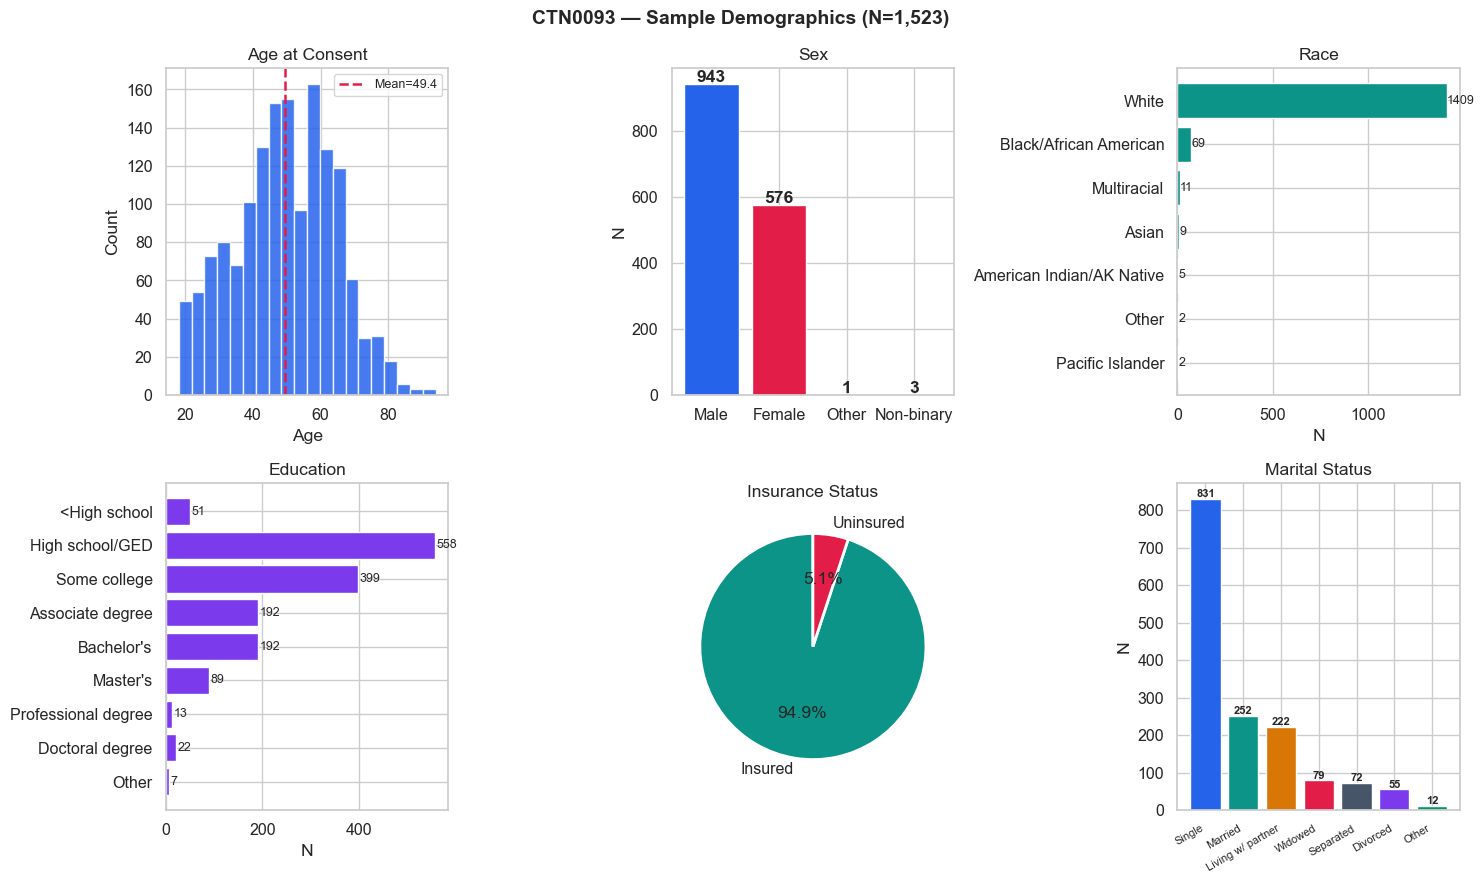

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('CTN0093 — Sample Demographics (N=1,523)', fontsize=14, fontweight='bold')

# Age histogram
axes[0,0].hist(df['AGEATCONSENT'].dropna(), bins=20, color=BLUE, edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['AGEATCONSENT'].mean(), color=ROSE, linestyle='--', linewidth=1.8, label=f'Mean={df["AGEATCONSENT"].mean():.1f}')
axes[0,0].set_title('Age at Consent'); axes[0,0].set_xlabel('Age'); axes[0,0].set_ylabel('Count')
axes[0,0].legend(fontsize=9)

# Sex
sex_c = df['SEX_LABEL'].value_counts().reindex(['Male','Female','Other','Non-binary']).dropna()
axes[0,1].bar(sex_c.index, sex_c.values, color=[BLUE, ROSE, TEAL, AMBER][:len(sex_c)])
axes[0,1].set_title('Sex'); axes[0,1].set_ylabel('N')
for i, v in enumerate(sex_c.values):
    axes[0,1].text(i, v+5, str(v), ha='center', fontweight='bold')

# Race
race_c = df['DEMOG_RACE'].map(race_map).value_counts()
axes[0,2].barh(race_c.index[::-1], race_c.values[::-1], color=TEAL)
axes[0,2].set_title('Race'); axes[0,2].set_xlabel('N')
for i, v in enumerate(race_c.values[::-1]):
    axes[0,2].text(v+3, i, str(v), va='center', fontsize=9)

# Education
edu_c = df['DEMOG_EDUCATION'].map(edu_map).value_counts()
edu_order = ['<High school','High school/GED','Some college','Associate degree',
             "Bachelor's","Master's",'Professional degree','Doctoral degree','Other']
edu_c = edu_c.reindex([e for e in edu_order if e in edu_c.index])
axes[1,0].barh(edu_c.index[::-1], edu_c.values[::-1], color=PURPLE)
axes[1,0].set_title('Education'); axes[1,0].set_xlabel('N')
for i, v in enumerate(edu_c.values[::-1]):
    axes[1,0].text(v+3, i, str(v), va='center', fontsize=9)

# Insurance
ins_c = df['INSURED_LABEL'].value_counts()
axes[1,1].pie(ins_c.values, labels=ins_c.index, autopct='%1.1f%%',
              colors=[TEAL, ROSE], startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[1,1].set_title('Insurance Status')

# Marital status
marital_map = {0:'Single', 1:'Married', 2:'Separated', 3:'Divorced', 4:'Living w/ partner', 5:'Widowed', 6:'Other'}
mar_c = df['DEMOG_MARITAL_STATUS'].map(marital_map).value_counts()
axes[1,2].bar(range(len(mar_c)), mar_c.values, color=COLORS[:len(mar_c)])
axes[1,2].set_xticks(range(len(mar_c)))
axes[1,2].set_xticklabels(mar_c.index, rotation=30, ha='right', fontsize=8)
axes[1,2].set_title('Marital Status'); axes[1,2].set_ylabel('N')
for i, v in enumerate(mar_c.values):
    axes[1,2].text(i, v+5, str(v), ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Recruitment & Pharmacy Initiation

In [4]:
print('=== Recruitment & Engagement ===')
print(f'  Total records                        : {N}')
print(f'  Initiated at pharmacy (in-person)    : {(df["INIT_AT_PHARMACY_YN"]==1).sum()} ({100*(df["INIT_AT_PHARMACY_YN"]==1).sum()/N:.1f}%)')
print(f'  Expressed initial interest           : {(df["INIT_INTEREST_YN"]==1).sum()} ({100*(df["INIT_INTEREST_YN"]==1).sum()/N:.1f}%)')
print(f'  Chose to participate                 : {(df["CHOOSE_TO_PARTICIPATE_YN"]==1).sum()} ({100*(df["CHOOSE_TO_PARTICIPATE_YN"]==1).sum()/N:.1f}%)')

print(f'\n  Invitation preference — SMS/Text     : {(df["INVITATION_PREFERENCE"]==1).sum()} ({100*(df["INVITATION_PREFERENCE"]==1).sum()/df["INVITATION_PREFERENCE"].notna().sum():.1f}%)')
print(f'  Invitation preference — Email        : {(df["INVITATION_PREFERENCE"]==2).sum()} ({100*(df["INVITATION_PREFERENCE"]==2).sum()/df["INVITATION_PREFERENCE"].notna().sum():.1f}%)')

# Pharmacy count
n_pharm = df['INT_PHARM_NAME'].nunique()
print(f'\n  Unique pharmacies                    : {n_pharm}')

# Pharmacy initiation by sex
print('\n  Pharmacy initiation by sex:')
init_sex = df[df['DEMOG_SEX'].isin([0,1])].groupby('SEX_LABEL')['INIT_AT_PHARMACY_YN'].value_counts(normalize=True).unstack().fillna(0)
init_sex.columns = ['Remote', 'In-person']
display((init_sex * 100).round(1))

=== Recruitment & Engagement ===
  Total records                        : 1523
  Initiated at pharmacy (in-person)    : 406 (26.7%)
  Expressed initial interest           : 1515 (99.5%)
  Chose to participate                 : 1523 (100.0%)

  Invitation preference — SMS/Text     : 871 (57.5%)
  Invitation preference — Email        : 644 (42.5%)

  Unique pharmacies                    : 20

  Pharmacy initiation by sex:


,Remote,In-person
SEX_LABEL,,
Female,73.40,26.60
Male,73.30,26.70


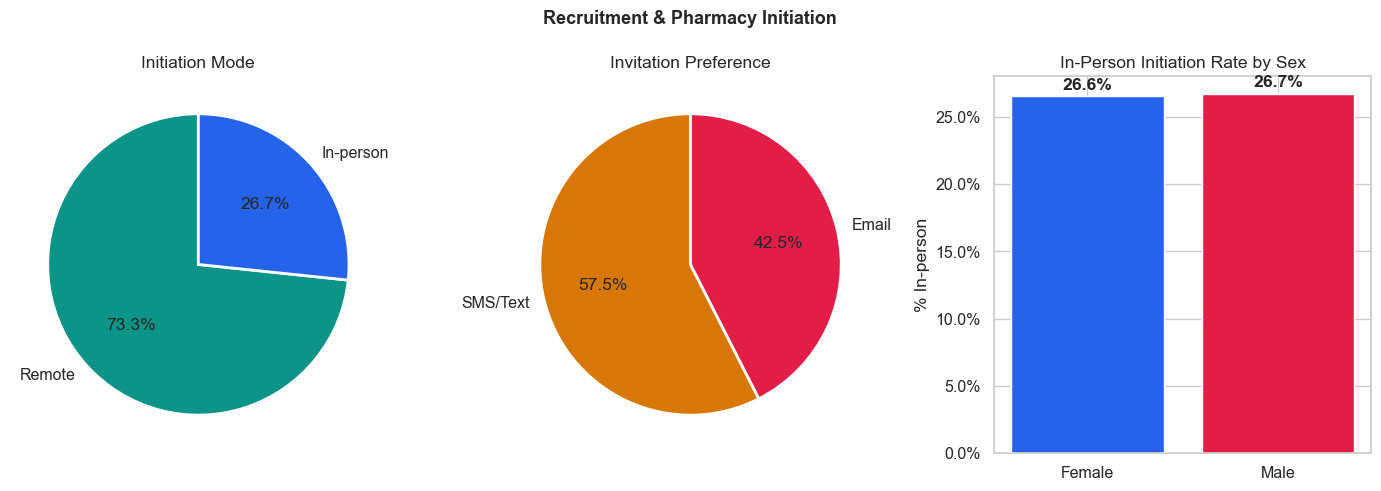

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Recruitment & Pharmacy Initiation', fontsize=13, fontweight='bold')

# Initiation mode
init_c = df['INIT_AT_PHARMACY_YN'].map({0:'Remote',1:'In-person'}).value_counts()
axes[0].pie(init_c.values, labels=init_c.index, autopct='%1.1f%%',
            colors=[TEAL, BLUE], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Initiation Mode')

# Invitation preference
inv_c = df['INVITE_LABEL'].value_counts()
axes[1].pie(inv_c.values, labels=inv_c.index, autopct='%1.1f%%',
            colors=[AMBER, ROSE], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Invitation Preference')

# In-person initiation rate by sex
main_sex = df[df['DEMOG_SEX'].isin([0,1])]
init_by_sex = main_sex.groupby('SEX_LABEL')['INIT_AT_PHARMACY_YN'].mean() * 100
bars = axes[2].bar(init_by_sex.index, init_by_sex.values, color=[BLUE, ROSE])
axes[2].set_title('In-Person Initiation Rate by Sex')
axes[2].set_ylabel('% In-person')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, v in zip(bars, init_by_sex.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_recruitment.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Pain Assessment (BPI)

The Brief Pain Inventory (BPI) captures pain severity (0–10) and pain interference with daily functioning (0–10 per item). Higher scores = worse pain.

In [6]:
bpi_severity = ['BPI_PAINSCALE_WORST','BPI_PAINSCALE_LEAST',
                 'BPI_PAINSCALE_AVERAGE','BPI_PAINSCALE_NOW']
bpi_severity_labels = ['Worst Pain','Least Pain','Average Pain','Pain Right Now']

bpi_interf_labels = ['Activity','Mood','Walking','Work','Relations','Sleep','Enjoyment']

print('BPI Severity Subscale (0–10, higher = worse)')
sev_df = pd.DataFrame({
    'Item': bpi_severity_labels,
    'N': [df[c].notna().sum() for c in bpi_severity],
    'Mean (SD)': [f"{df[c].mean():.2f} ({df[c].std():.2f})" for c in bpi_severity],
    'Median [IQR]': [f"{df[c].median():.0f} [{df[c].quantile(.25):.0f}–{df[c].quantile(.75):.0f}]" for c in bpi_severity],
}).set_index('Item')
display(sev_df)

print('\nBPI Interference Subscale (0–10 per item)')
interf_df = pd.DataFrame({
    'Item': bpi_interf_labels,
    'N': [df[c].notna().sum() for c in bpi_interf],
    'Mean (SD)': [f"{df[c].mean():.2f} ({df[c].std():.2f})" for c in bpi_interf],
    'Median [IQR]': [f"{df[c].median():.0f} [{df[c].quantile(.25):.0f}–{df[c].quantile(.75):.0f}]" for c in bpi_interf],
}).set_index('Item')
display(interf_df)

print(f"\nBPI Interference Mean (composite): {df['BPI_INTERFERENCE_MEAN'].mean():.2f} (SD={df['BPI_INTERFERENCE_MEAN'].std():.2f})")
print(f"BPI Pain Relief: {df['BPI_PAIN_SCALE_RELIEF_1'].mean():.1f}% mean relief (SD={df['BPI_PAIN_SCALE_RELIEF_1'].std():.1f})")

BPI Severity Subscale (0–10, higher = worse)


,N,Mean (SD),Median [IQR]
Item,,,
Worst Pain,1519,6.31 (2.55),7 [5–8]
Least Pain,1519,3.70 (2.63),3 [2–5]
Average Pain,1519,4.73 (2.40),5 [3–6]
Pain Right Now,1518,4.59 (2.73),5 [2–7]



BPI Interference Subscale (0–10 per item)


,N,Mean (SD),Median [IQR]
Item,,,
Activity,1515,5.55 (3.17),6 [3–8]
Mood,1515,4.57 (3.22),5 [2–7]
Walking,1514,4.76 (3.55),5 [1–8]
Work,1511,5.64 (3.43),6 [3–9]
Relations,1514,3.01 (3.13),2 [0–5]
Sleep,1515,5.28 (3.30),6 [3–8]
Enjoyment,1512,4.90 (3.41),5 [2–8]



BPI Interference Mean (composite): 4.81 (SD=2.76)
BPI Pain Relief: 6.0% mean relief (SD=2.4)


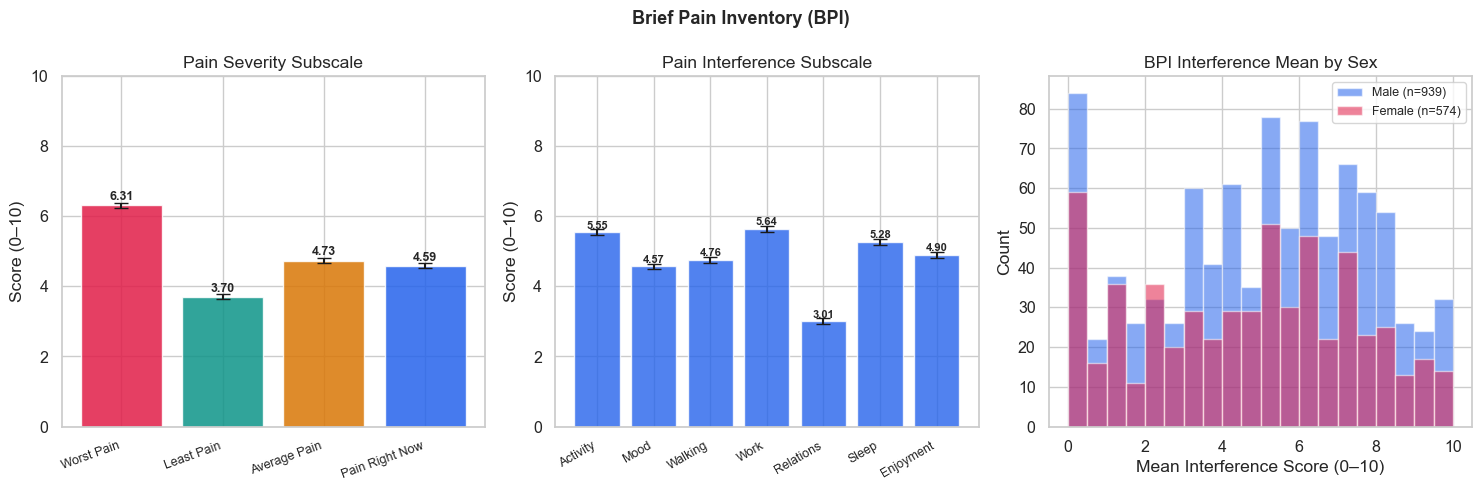

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Brief Pain Inventory (BPI)', fontsize=13, fontweight='bold')

# Severity subscale means
sev_means = [df[c].mean() for c in bpi_severity]
sev_sems  = [df[c].sem()  for c in bpi_severity]
bars = axes[0].bar(bpi_severity_labels, sev_means, yerr=sev_sems, capsize=5,
                   color=[ROSE, TEAL, AMBER, BLUE], alpha=0.85)
axes[0].set_title('Pain Severity Subscale'); axes[0].set_ylabel('Score (0–10)')
axes[0].set_ylim(0, 10)
axes[0].set_xticklabels(bpi_severity_labels, rotation=20, ha='right', fontsize=9)
for bar, v in zip(bars, sev_means):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.15, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

# Interference subscale means
interf_means = [df[c].mean() for c in bpi_interf]
interf_sems  = [df[c].sem()  for c in bpi_interf]
bars2 = axes[1].bar(bpi_interf_labels, interf_means, yerr=interf_sems, capsize=5,
                    color=BLUE, alpha=0.80)
axes[1].set_title('Pain Interference Subscale'); axes[1].set_ylabel('Score (0–10)')
axes[1].set_ylim(0, 10)
axes[1].set_xticklabels(bpi_interf_labels, rotation=30, ha='right', fontsize=9)
for bar, v in zip(bars2, interf_means):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.2f}', ha='center', fontsize=8, fontweight='bold')

# BPI interference distribution by sex
for sex, color, lbl in [(0, BLUE,'Male'),(1, ROSE,'Female')]:
    vals = df[df['DEMOG_SEX']==sex]['BPI_INTERFERENCE_MEAN'].dropna()
    axes[2].hist(vals, bins=20, alpha=0.55, color=color, label=f'{lbl} (n={len(vals)})', edgecolor='white')
axes[2].set_title('BPI Interference Mean by Sex')
axes[2].set_xlabel('Mean Interference Score (0–10)')
axes[2].set_ylabel('Count')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_bpi.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# BPI by sex — Mann-Whitney U
print('BPI by Sex (Male vs Female) — Mann-Whitney U')
for col, lbl in zip(bpi_severity + bpi_interf, bpi_severity_labels + bpi_interf_labels):
    m = df[df['DEMOG_SEX']==0][col].dropna()
    f = df[df['DEMOG_SEX']==1][col].dropna()
    if len(m)>5 and len(f)>5:
        u, p = stats.mannwhitneyu(m, f, alternative='two-sided')
        sig = '**' if p < 0.01 else ('*' if p < 0.05 else '')
        print(f'  {lbl:20s} | M median={m.median():.1f}  F median={f.median():.1f}  U={u:.0f}  p={p:.3f} {sig}')

BPI by Sex (Male vs Female) — Mann-Whitney U
  Worst Pain           | M median=7.0  F median=7.0  U=291106  p=0.011 *
  Least Pain           | M median=4.0  F median=3.0  U=290507  p=0.013 *
  Average Pain         | M median=5.0  F median=5.0  U=288104  p=0.029 *
  Pain Right Now       | M median=5.0  F median=4.0  U=293968  p=0.003 **
  Activity             | M median=6.0  F median=5.0  U=294760  p=0.001 **
  Mood                 | M median=5.0  F median=5.0  U=281913  p=0.107 
  Walking              | M median=5.0  F median=4.0  U=287928  p=0.015 *
  Work                 | M median=6.0  F median=6.0  U=281886  p=0.065 
  Relations            | M median=2.0  F median=2.0  U=278598  p=0.203 
  Sleep                | M median=6.0  F median=5.0  U=282564  p=0.091 
  Enjoyment            | M median=5.0  F median=5.0  U=280523  p=0.116 


## 5. Opioid & Substance Use History (ASSIST)

ASSIST items capture lifetime use (ever) and recent (3-month) use across substances. "Ever" is coded as 3 = yes.

In [9]:
assist_substances = {
    'Tobacco':          ('ASSIST_EVER_TOBACCO',       'ASSIST_3MONTH_TOBACCO'),
    'Alcohol':          ('ASSIST_EVER_ALCOHOL',       'ASSIST_3MONTH_ALCOHOL'),
    'Cannabis':         ('ASSIST_EVER_CANNABIS',      None),
    'Cocaine':          ('ASSIST_EVER_COCAINE',       None),
    'Rx Stimulants':    ('ASSIST_EVER_RX_STIMULANT',  None),
    'Methamphetamine':  ('ASSIST_EVER_METH',          None),
    'Inhalants':        ('ASSIST_EVER_INHALANTS',     None),
    'Sedatives':        ('ASSIST_EVER_SEDATIVES',     None),
    'Hallucinogens':    ('ASSIST_EVER_HALLUCINOGEN',  None),
    'Street Opioids':   ('ASSIST_EVER_STREET_OPIOID', None),
    'Rx Opioids':       ('ASSIST_EVER_RX_OPIOID',    'ASSIST_3MONTH_RX_OPIOID'),
}

rows = []
for substance, (ever_col, month3_col) in assist_substances.items():
    n_ever = (df[ever_col] == 3).sum()
    tot_ever = df[ever_col].notna().sum()
    row = {
        'Substance': substance,
        'Ever Used N': n_ever,
        'Ever Used %': f'{100*n_ever/tot_ever:.1f}%' if tot_ever else 'N/A',
    }
    if month3_col:
        n_3m = df[month3_col].notna().sum()
        row['Recent Use N (3mo)'] = n_3m
        row['Recent Use %'] = f'{100*n_3m/N:.1f}%'
    else:
        row['Recent Use N (3mo)'] = 'N/A (high missing)'
        row['Recent Use %'] = '—'
    rows.append(row)

assist_df = pd.DataFrame(rows).set_index('Substance')
print(f'ASSIST — Substance Use History (N={N})')
display(assist_df)

# Injection
n_inject = (df['ASSIST_INJECT'].isin([1, 2])).sum()
print(f'\nEver injected drugs: {n_inject} ({100*n_inject/N:.1f}%)')
n_inject3m = (df['ASSIST_INJECT'] == 2).sum()
print(f'Injected in past 3 months: {n_inject3m} ({100*n_inject3m/N:.1f}%)')

ASSIST — Substance Use History (N=1523)


,Ever Used N,Ever Used %,Recent Use N (3mo),Recent Use %
Substance,,,,
Tobacco,900,59.4%,893,58.6%
Alcohol,1150,76.0%,1147,75.3%
Cannabis,550,36.5%,N/A (high missing),—
Cocaine,153,10.2%,N/A (high missing),—
Rx Stimulants,219,14.5%,N/A (high missing),—
Methamphetamine,71,4.7%,N/A (high missing),—
Inhalants,42,2.8%,N/A (high missing),—
Sedatives,480,31.7%,N/A (high missing),—
Hallucinogens,148,9.8%,N/A (high missing),—



Ever injected drugs: 58 (3.8%)
Injected in past 3 months: 16 (1.1%)


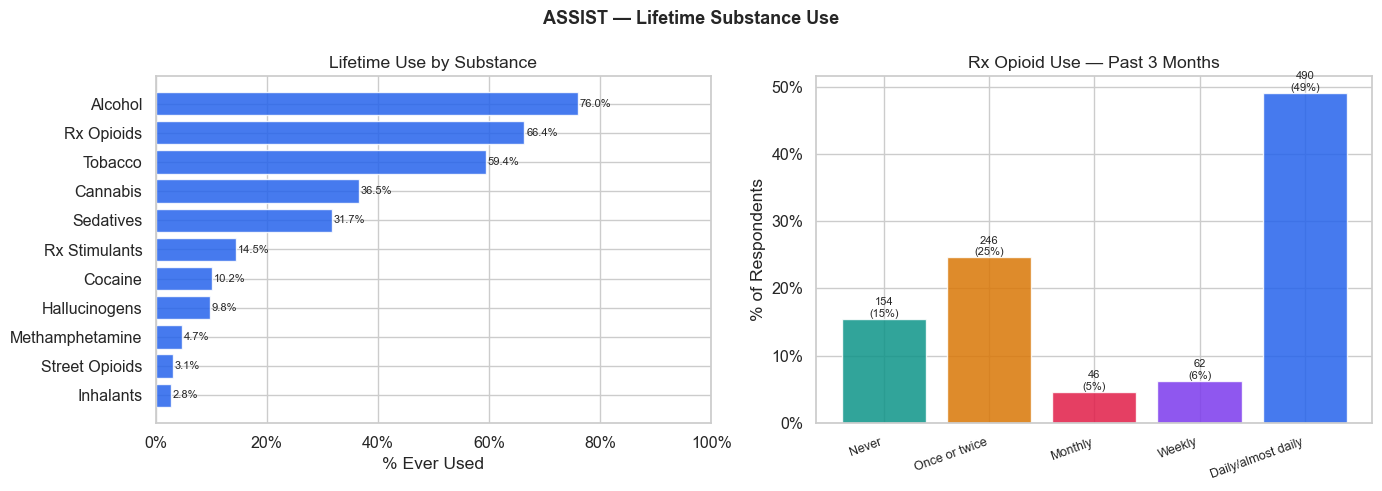

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ASSIST — Lifetime Substance Use', fontsize=13, fontweight='bold')

# Ever use rates
subs = list(assist_substances.keys())
ever_pcts = []
for s, (ever_col, _) in assist_substances.items():
    n = (df[ever_col] == 3).sum()
    tot = df[ever_col].notna().sum()
    ever_pcts.append(100*n/tot if tot else 0)

sorted_idx = sorted(range(len(ever_pcts)), key=lambda i: ever_pcts[i])
subs_sorted = [subs[i] for i in sorted_idx]
pcts_sorted = [ever_pcts[i] for i in sorted_idx]

bars = axes[0].barh(subs_sorted, pcts_sorted, color=BLUE, alpha=0.85)
axes[0].set_xlabel('% Ever Used')
axes[0].set_title('Lifetime Use by Substance')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
for bar, v in zip(bars, pcts_sorted):
    axes[0].text(v+0.3, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=8)
axes[0].set_xlim(0, 100)

# Rx opioid 3-month use frequency
rx_3m_map = {0:'Never', 2:'Once or twice', 3:'Monthly', 4:'Weekly', 6:'Daily/almost daily'}
rx_c = df['ASSIST_3MONTH_RX_OPIOID'].map(rx_3m_map).value_counts()
rx_order = [v for v in ['Never','Once or twice','Monthly','Weekly','Daily/almost daily'] if v in rx_c]
rx_c = rx_c.reindex(rx_order)
axes[1].bar(range(len(rx_c)), (rx_c/rx_c.sum()*100).values,
            color=[TEAL, AMBER, ROSE, PURPLE, BLUE][:len(rx_c)], alpha=0.85)
axes[1].set_xticks(range(len(rx_c)))
axes[1].set_xticklabels(rx_c.index, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('% of Respondents')
axes[1].set_title('Rx Opioid Use — Past 3 Months')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, (v, n_) in enumerate(zip((rx_c/rx_c.sum()*100).values, rx_c.values)):
    axes[1].text(i, v+0.3, f'{int(n_)}\n({v:.0f}%)', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig_assist.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Opioid Misuse Indicators (POMI)

The POMI captures six opioid misuse behaviors (each binary: 0=No, 1=Yes).

In [11]:
pomi_labels = {
    'POMI_MORE_THAN_PRESCRIBED':  'Used more than prescribed (dose)',
    'POMI_MORE_OFTEN_THAN_PRESCR':'Used more than prescribed (frequency)',
    'POMI_EARLY_REFILLS':          'Sought early refills',
    'POMI_FEEL_HIGH':              'Used to feel high',
    'POMI_UPSET':                  'Used when upset/emotional',
    'POMI_MULTIPLE_PHYSICIANS':    'Used multiple prescribers',
}

pomi_rows = []
for col, lbl in pomi_labels.items():
    n_yes = (df[col] == 1).sum()
    n_tot = df[col].notna().sum()
    pomi_rows.append({'Behavior': lbl, 'N Yes': n_yes, '% Yes': f'{100*n_yes/n_tot:.1f}%'})
pomi_df = pd.DataFrame(pomi_rows).set_index('Behavior')
print(f'POMI — Opioid Misuse Indicators (N={N})')
display(pomi_df)

print(f"\nAny POMI item endorsed (POMI_ANY): {df['POMI_ANY'].sum():.0f} ({100*df['POMI_ANY'].mean():.1f}%)")
print(f"POMI Total score — mean (SD)      : {df['POMI_TOTAL'].mean():.2f} ({df['POMI_TOTAL'].std():.2f})")
print(f"POMI Total score — median [IQR]   : {df['POMI_TOTAL'].median():.0f} [{df['POMI_TOTAL'].quantile(.25):.0f}–{df['POMI_TOTAL'].quantile(.75):.0f}]")

# POMI any by sex
print('\nPOMI_ANY by sex:')
for sex, lbl in [(0,'Male'),(1,'Female')]:
    sub = df[df['DEMOG_SEX']==sex]
    n = sub['POMI_ANY'].sum()
    pct = 100*sub['POMI_ANY'].mean()
    print(f'  {lbl}: {int(n)} / {len(sub)} ({pct:.1f}%)')

POMI — Opioid Misuse Indicators (N=1523)


,N Yes,% Yes
Behavior,,
Used more than prescribed (dose),141,9.3%
Used more than prescribed (frequency),222,14.6%
Sought early refills,73,4.8%
Used to feel high,203,13.4%
Used when upset/emotional,42,2.8%
Used multiple prescribers,17,1.1%



Any POMI item endorsed (POMI_ANY): 411 (27.0%)
POMI Total score — mean (SD)      : 0.46 (0.92)
POMI Total score — median [IQR]   : 0 [0–1]

POMI_ANY by sex:
  Male: 244 / 943 (25.9%)
  Female: 167 / 576 (29.0%)


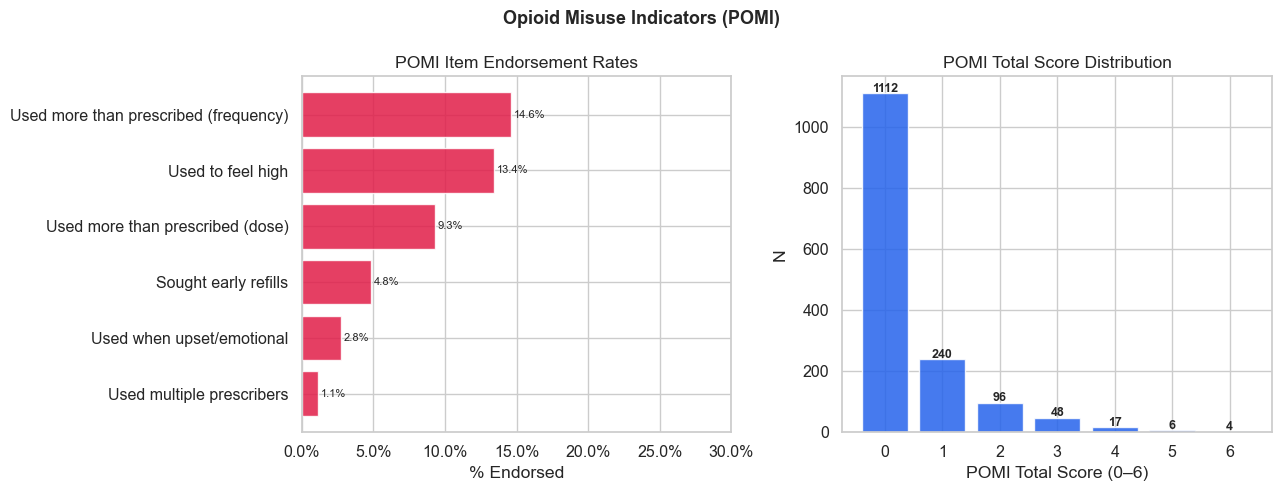

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Opioid Misuse Indicators (POMI)', fontsize=13, fontweight='bold')

# Item-level rates
pomi_pcts = [(df[c]==1).sum()/df[c].notna().sum()*100 for c in pomi_labels]
pomi_lbls = [lbl[:40] for lbl in pomi_labels.values()]
sorted_idx = sorted(range(len(pomi_pcts)), key=lambda i: pomi_pcts[i])
bars = axes[0].barh([pomi_lbls[i] for i in sorted_idx],
                    [pomi_pcts[i] for i in sorted_idx], color=ROSE, alpha=0.85)
axes[0].set_xlabel('% Endorsed')
axes[0].set_title('POMI Item Endorsement Rates')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
for bar, v in zip(bars, [pomi_pcts[i] for i in sorted_idx]):
    axes[0].text(v+0.2, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=8)
axes[0].set_xlim(0, 30)

# POMI total distribution
pomi_vc = df['POMI_TOTAL'].value_counts().sort_index()
axes[1].bar(pomi_vc.index, pomi_vc.values, color=BLUE, alpha=0.85)
axes[1].set_xlabel('POMI Total Score (0–6)')
axes[1].set_ylabel('N')
axes[1].set_title('POMI Total Score Distribution')
for i, (x, v) in enumerate(pomi_vc.items()):
    axes[1].text(x, v+5, str(int(v)), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_pomi.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Depression Screening (PHQ-2)

PHQ-2 items: interest/pleasure (0–3) + depressed mood (0–3). Total 0–6; score ≥ 3 = positive screen for depression.

In [13]:
phq2_valid = df['PHQ2_TOTAL'].dropna()
print(f'PHQ-2 — Depression Screening (n={len(phq2_valid)})')
print(f'  Mean (SD)       : {phq2_valid.mean():.2f} ({phq2_valid.std():.2f})')
print(f'  Median [IQR]    : {phq2_valid.median():.0f} [{phq2_valid.quantile(.25):.0f}–{phq2_valid.quantile(.75):.0f}]')
n_pos = (phq2_valid >= 3).sum()
print(f'  Positive screen (≥3): {n_pos} ({100*n_pos/len(phq2_valid):.1f}%)')

print('\nPHQ-2 by sex:')
for sex, lbl in [(0,'Male'),(1,'Female')]:
    sub = df[df['DEMOG_SEX']==sex]['PHQ2_TOTAL'].dropna()
    pos = (sub >= 3).sum()
    print(f'  {lbl}: mean={sub.mean():.2f}, median={sub.median():.0f}, positive screen={pos} ({100*pos/len(sub):.1f}%)')

# Correlation: PHQ-2 vs BPI interference
corr_df = df[['PHQ2_TOTAL','BPI_INTERFERENCE_MEAN']].dropna()
r, p = stats.spearmanr(corr_df['PHQ2_TOTAL'], corr_df['BPI_INTERFERENCE_MEAN'])
print(f'\nSpearman correlation PHQ-2 vs BPI Interference: r={r:.3f}, p={p:.4f}')

PHQ-2 — Depression Screening (n=1493)
  Mean (SD)       : 1.39 (1.79)
  Median [IQR]    : 1 [0–2]
  Positive screen (≥3): 297 (19.9%)

PHQ-2 by sex:
  Male: mean=1.53, median=1, positive screen=212 (22.9%)
  Female: mean=1.17, median=0, positive screen=84 (14.9%)

Spearman correlation PHQ-2 vs BPI Interference: r=0.442, p=0.0000


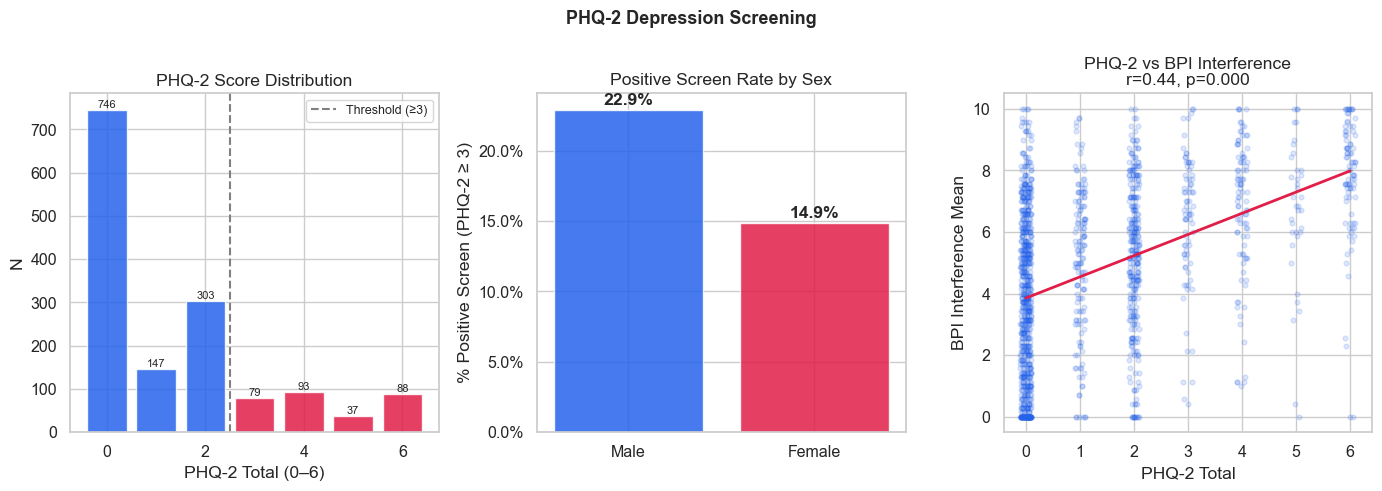

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('PHQ-2 Depression Screening', fontsize=13, fontweight='bold')

# PHQ-2 distribution
phq2_vc = df['PHQ2_TOTAL'].value_counts().sort_index()
axes[0].bar(phq2_vc.index, phq2_vc.values,
            color=[ROSE if x >= 3 else BLUE for x in phq2_vc.index], alpha=0.85)
axes[0].axvline(2.5, color='gray', linestyle='--', linewidth=1.5, label='Threshold (≥3)')
axes[0].set_xlabel('PHQ-2 Total (0–6)'); axes[0].set_ylabel('N')
axes[0].set_title('PHQ-2 Score Distribution')
axes[0].legend(fontsize=9)
for x, v in phq2_vc.items():
    axes[0].text(x, v+5, str(int(v)), ha='center', fontsize=8)

# Positive screen by sex
phq_sex = {}
for sex, lbl in [(0,'Male'),(1,'Female')]:
    sub = df[df['DEMOG_SEX']==sex]['PHQ2_TOTAL'].dropna()
    phq_sex[lbl] = 100*(sub>=3).sum()/len(sub)
bars = axes[1].bar(phq_sex.keys(), phq_sex.values(), color=[BLUE, ROSE], alpha=0.85)
axes[1].set_ylabel('% Positive Screen (PHQ-2 ≥ 3)')
axes[1].set_title('Positive Screen Rate by Sex')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, v in zip(bars, phq_sex.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# PHQ-2 vs BPI scatter
corr_df = df[['PHQ2_TOTAL','BPI_INTERFERENCE_MEAN']].dropna()
axes[2].scatter(corr_df['PHQ2_TOTAL'] + np.random.uniform(-0.1,0.1,len(corr_df)),
                corr_df['BPI_INTERFERENCE_MEAN'],
                alpha=0.15, s=12, color=BLUE)
m, b = np.polyfit(corr_df['PHQ2_TOTAL'], corr_df['BPI_INTERFERENCE_MEAN'], 1)
x_line = np.linspace(0, 6, 50)
axes[2].plot(x_line, m*x_line+b, color=ROSE, linewidth=2)
axes[2].set_xlabel('PHQ-2 Total'); axes[2].set_ylabel('BPI Interference Mean')
axes[2].set_title(f'PHQ-2 vs BPI Interference\nr={r:.2f}, p={p:.3f}')

plt.tight_layout()
plt.savefig('fig_phq2.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. General Health & Overdose History

In [15]:
# SF-12 General Health
sf12_map = {0:'Excellent', 1:'Very Good', 2:'Good', 3:'Fair', 4:'Poor'}
sf12_c = df['SF12_GENERALHEALTH'].map(sf12_map).value_counts()
sf12_order = ['Excellent','Very Good','Good','Fair','Poor']
sf12_c = sf12_c.reindex([s for s in sf12_order if s in sf12_c])

print('SF-12 General Health Rating:')
for lbl, n in sf12_c.items():
    print(f'  {lbl:<15}: {int(n):>5}  ({100*n/sf12_c.sum():.1f}%)')

# Overdose history
od = df['OESWD_PERSONAL_OVERDOSES'].dropna()
n_any_od = (od > 0).sum()
print(f'\nOverdose History:')
print(f'  Any personal overdose      : {int(n_any_od)} ({100*n_any_od/len(od):.1f}%)')
print(f'  Mean overdoses (among any) : {od[od>0].mean():.2f} (SD={od[od>0].std():.2f})')
print(f'  Overdose count distribution:')
for v, n in od.value_counts().sort_index().items():
    if v <= 6:
        print(f'    {int(v)} overdoses: {int(n)} ({100*n/len(od):.1f}%)')

# Overdose by sex
print('\nAny overdose by sex:')
for sex, lbl in [(0,'Male'),(1,'Female')]:
    sub = df[df['DEMOG_SEX']==sex]['OESWD_PERSONAL_OVERDOSES'].dropna()
    n = (sub > 0).sum()
    print(f'  {lbl}: {int(n)} / {len(sub)} ({100*n/len(sub):.1f}%)')

SF-12 General Health Rating:
  Excellent      :   152  (10.0%)
  Very Good      :   463  (30.5%)
  Good           :   585  (38.5%)
  Fair           :   260  (17.1%)
  Poor           :    58  (3.8%)

Overdose History:
  Any personal overdose      : 148 (9.8%)
  Mean overdoses (among any) : 2.47 (SD=1.76)
  Overdose count distribution:
    0 overdoses: 1368 (90.2%)
    1 overdoses: 59 (3.9%)
    2 overdoses: 43 (2.8%)
    3 overdoses: 13 (0.9%)
    4 overdoses: 4 (0.3%)
    5 overdoses: 9 (0.6%)
    6 overdoses: 20 (1.3%)

Any overdose by sex:
  Male: 96 / 938 (10.2%)
  Female: 52 / 574 (9.1%)


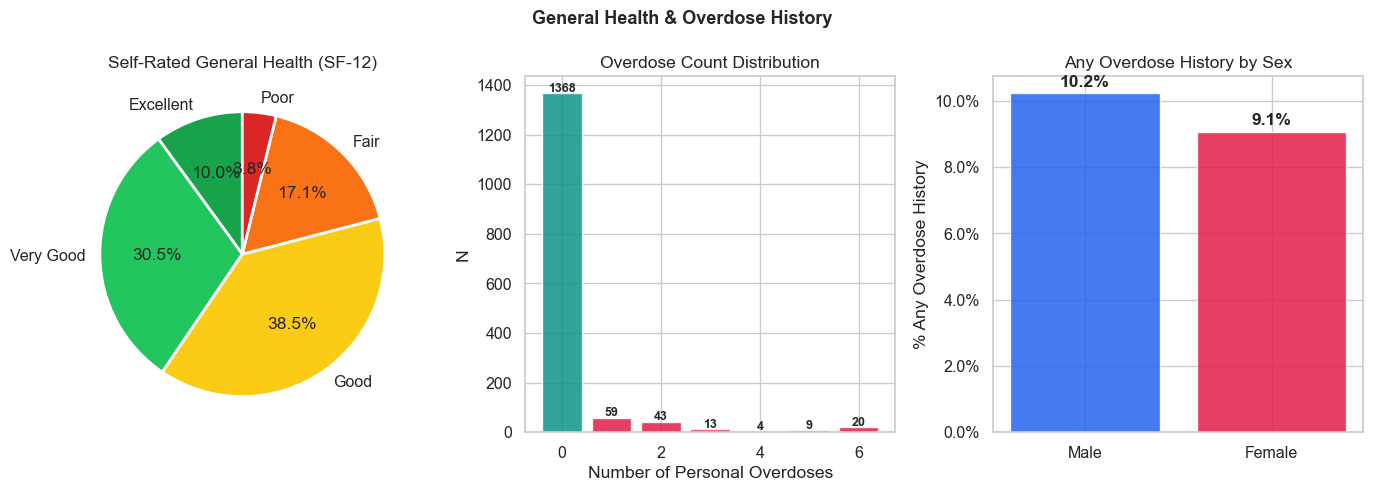

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('General Health & Overdose History', fontsize=13, fontweight='bold')

# SF-12 pie
sf12_colors = ['#16A34A','#22C55E','#FACC15','#F97316','#DC2626']
axes[0].pie(sf12_c.values, labels=sf12_c.index, autopct='%1.1f%%',
            colors=sf12_colors[:len(sf12_c)], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Self-Rated General Health (SF-12)')

# Overdose count
od_vc = od.value_counts().sort_index()
od_vc = od_vc[od_vc.index <= 6]
axes[1].bar(od_vc.index, od_vc.values, color=[TEAL if x==0 else ROSE for x in od_vc.index], alpha=0.85)
axes[1].set_xlabel('Number of Personal Overdoses')
axes[1].set_ylabel('N')
axes[1].set_title('Overdose Count Distribution')
for x, v in od_vc.items():
    axes[1].text(x, v+5, str(int(v)), ha='center', fontsize=9, fontweight='bold')

# Overdose by sex
od_sex_pct = {}
for sex, lbl in [(0,'Male'),(1,'Female')]:
    sub = df[df['DEMOG_SEX']==sex]['OESWD_PERSONAL_OVERDOSES'].dropna()
    od_sex_pct[lbl] = 100*(sub>0).sum()/len(sub)
bars = axes[2].bar(od_sex_pct.keys(), od_sex_pct.values(), color=[BLUE, ROSE], alpha=0.85)
axes[2].set_ylabel('% Any Overdose History')
axes[2].set_title('Any Overdose History by Sex')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, v in zip(bars, od_sex_pct.values()):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_health_overdose.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Narcotic Risk Score (NarxScore)

NarxScore is a prescription drug monitoring program (PDMP) risk score. Higher scores indicate greater opioid-related risk. Non-numeric entries (e.g., "Not in Appriss Database") are excluded from numeric analyses.

In [17]:
narx = df['NARCOTICSCORE_NUM'].dropna()
n_nonnumeric = (df['NARCOTICSCORE'] == 'Not in Appriss Database').sum()
n_zero = (narx == 0).sum()

print(f'NarxScore (PDMP Risk Score)')
print(f'  Total records          : {len(df)}')
print(f'  Not in Appriss DB      : {n_nonnumeric} ({100*n_nonnumeric/len(df):.1f}%)')
print(f'  Numeric scores (n)     : {len(narx)}')
print(f'  Score = 0 (no Rx risk) : {n_zero} ({100*n_zero/len(narx):.1f}%)')
print(f'  Mean (SD)              : {narx.mean():.1f} ({narx.std():.1f})')
print(f'  Median [IQR]           : {narx.median():.0f} [{narx.quantile(.25):.0f}–{narx.quantile(.75):.0f}]')
print(f'  Min – Max              : {narx.min():.0f} – {narx.max():.0f}')

# Risk tiers (common NarxScore thresholds)
tiers = pd.cut(narx, bins=[-1, 0, 200, 400, 700], labels=['0 (No risk)','1–200 (Low)','201–400 (Moderate)','401+ (High)'])
print('\nNarxScore Risk Tiers:')
for tier, cnt in tiers.value_counts().sort_index().items():
    print(f'  {tier:<25}: {int(cnt):>5} ({100*cnt/len(narx):.1f}%)')

# Correlation with BPI
corr_df2 = df[['NARCOTICSCORE_NUM','BPI_PAINSCALE_AVERAGE','POMI_TOTAL']].dropna()
r_bpi, p_bpi = stats.spearmanr(corr_df2['NARCOTICSCORE_NUM'], corr_df2['BPI_PAINSCALE_AVERAGE'])
r_pomi, p_pomi = stats.spearmanr(corr_df2['NARCOTICSCORE_NUM'], corr_df2['POMI_TOTAL'])
print(f'\nSpearman: NarxScore vs BPI Average Pain : r={r_bpi:.3f}, p={p_bpi:.4f}')
print(f'Spearman: NarxScore vs POMI Total       : r={r_pomi:.3f}, p={p_pomi:.4f}')

NarxScore (PDMP Risk Score)
  Total records          : 1523
  Not in Appriss DB      : 59 (3.9%)
  Numeric scores (n)     : 1464
  Score = 0 (no Rx risk) : 32 (2.2%)
  Mean (SD)              : 275.1 (146.9)
  Median [IQR]           : 281 [131–390]
  Min – Max              : 0 – 692

NarxScore Risk Tiers:
  0 (No risk)              :    32 (2.2%)
  1–200 (Low)              :   503 (34.4%)
  201–400 (Moderate)       :   596 (40.7%)
  401+ (High)              :   333 (22.7%)

Spearman: NarxScore vs BPI Average Pain : r=0.397, p=0.0000
Spearman: NarxScore vs POMI Total       : r=0.090, p=0.0006


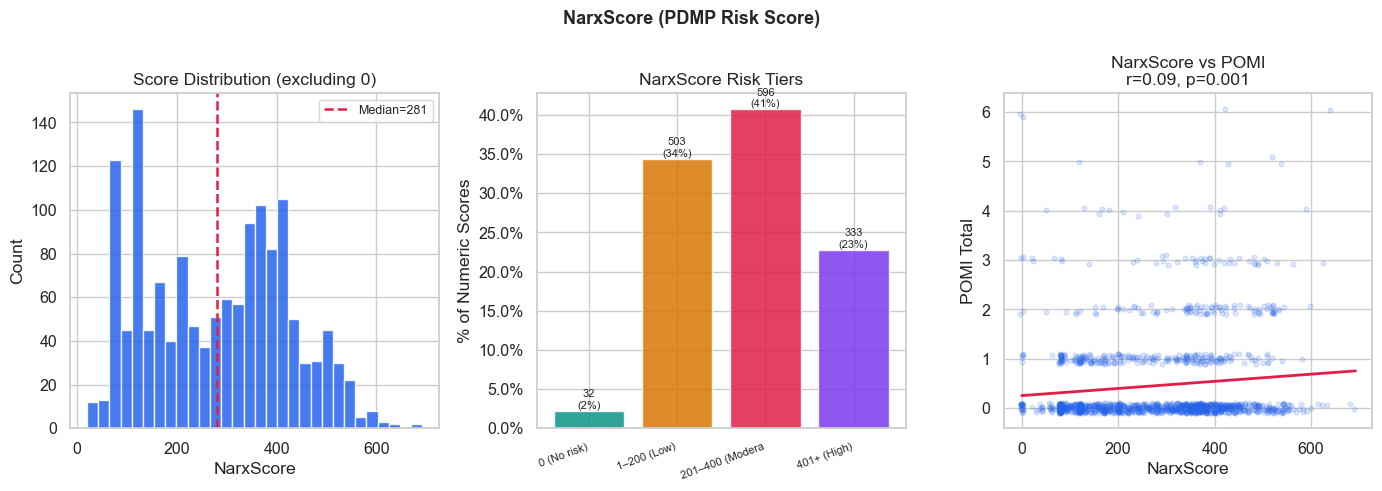

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('NarxScore (PDMP Risk Score)', fontsize=13, fontweight='bold')

# Distribution
axes[0].hist(narx[narx > 0], bins=30, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].axvline(narx.median(), color=ROSE, linestyle='--', linewidth=1.8, label=f'Median={narx.median():.0f}')
axes[0].set_xlabel('NarxScore'); axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution (excluding 0)')
axes[0].legend(fontsize=9)

# Risk tiers
tier_c = tiers.value_counts().sort_index()
axes[1].bar(range(len(tier_c)), 100*tier_c.values/len(narx),
            color=[TEAL, AMBER, ROSE, '#7C3AED'][:len(tier_c)], alpha=0.85)
axes[1].set_xticks(range(len(tier_c)))
axes[1].set_xticklabels([str(t)[:15] for t in tier_c.index], rotation=20, ha='right', fontsize=8)
axes[1].set_ylabel('% of Numeric Scores')
axes[1].set_title('NarxScore Risk Tiers')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, (v, n_) in enumerate(zip(100*tier_c.values/len(narx), tier_c.values)):
    axes[1].text(i, v+0.3, f'{int(n_)}\n({v:.0f}%)', ha='center', fontsize=8)

# NarxScore vs POMI scatter
axes[2].scatter(
    corr_df2['NARCOTICSCORE_NUM'] + np.random.uniform(-3,3,len(corr_df2)),
    corr_df2['POMI_TOTAL'] + np.random.uniform(-0.1,0.1,len(corr_df2)),
    alpha=0.15, s=12, color=BLUE
)
m2, b2 = np.polyfit(corr_df2['NARCOTICSCORE_NUM'], corr_df2['POMI_TOTAL'], 1)
x2 = np.linspace(narx.min(), narx.max(), 100)
axes[2].plot(x2, m2*x2+b2, color=ROSE, linewidth=2)
axes[2].set_xlabel('NarxScore'); axes[2].set_ylabel('POMI Total')
axes[2].set_title(f'NarxScore vs POMI\nr={r_pomi:.2f}, p={p_pomi:.3f}')

plt.tight_layout()
plt.savefig('fig_narxscore.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Heatmap — Key Outcomes by Subgroup

Two heatmaps:
1. **Mean outcome scores** across sex × insurance subgroups, z-scored within each measure.
2. **POMI item endorsement rates (%)** by sex.

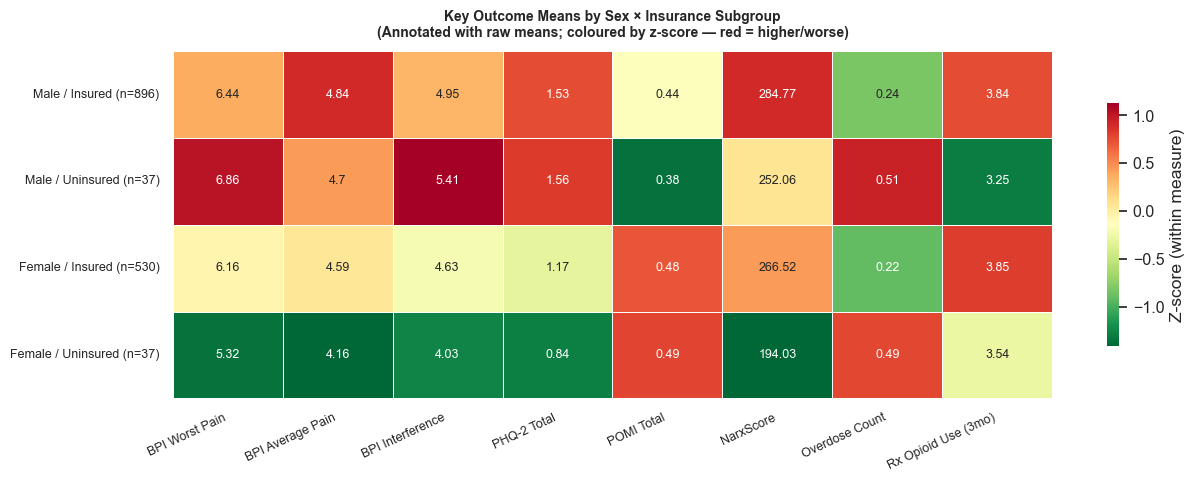

In [19]:
# ── 10a. Outcome heatmap by Sex × Insurance ───────────────────────────────────
hm_measures = {
    'BPI Worst Pain':        'BPI_PAINSCALE_WORST',
    'BPI Average Pain':      'BPI_PAINSCALE_AVERAGE',
    'BPI Interference':      'BPI_INTERFERENCE_MEAN',
    'PHQ-2 Total':           'PHQ2_TOTAL',
    'POMI Total':            'POMI_TOTAL',
    'NarxScore':             'NARCOTICSCORE_NUM',
    'Overdose Count':        'OESWD_PERSONAL_OVERDOSES',
    'Rx Opioid Use (3mo)':   'ASSIST_3MONTH_RX_OPIOID',
}

subgroups = {
    'Male / Insured':     (df['DEMOG_SEX']==0) & (df['DEMOG_ARE_YOU_INSURED']==1),
    'Male / Uninsured':   (df['DEMOG_SEX']==0) & (df['DEMOG_ARE_YOU_INSURED']==0),
    'Female / Insured':   (df['DEMOG_SEX']==1) & (df['DEMOG_ARE_YOU_INSURED']==1),
    'Female / Uninsured': (df['DEMOG_SEX']==1) & (df['DEMOG_ARE_YOU_INSURED']==0),
}

hm_data = {}
for sg_name, mask in subgroups.items():
    n_sg = mask.sum()
    row_label = f'{sg_name} (n={n_sg})'
    hm_data[row_label] = {
        lbl: df.loc[mask, col].mean()
        for lbl, col in hm_measures.items()
    }

hm_df = pd.DataFrame(hm_data).T

# Z-score across subgroups for each measure
hm_z = hm_df.apply(lambda col: (col - col.mean()) / (col.std() + 1e-9), axis=0)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    hm_z,
    ax=ax,
    cmap='RdYlGn_r',
    annot=hm_df.round(2),
    fmt='g',
    annot_kws={'size': 9},
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Z-score (within measure)', 'shrink': 0.7}
)
ax.set_title('Key Outcome Means by Sex × Insurance Subgroup\n(Annotated with raw means; coloured by z-score — red = higher/worse)',
             fontsize=10, fontweight='bold', pad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('fig_heatmap_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()

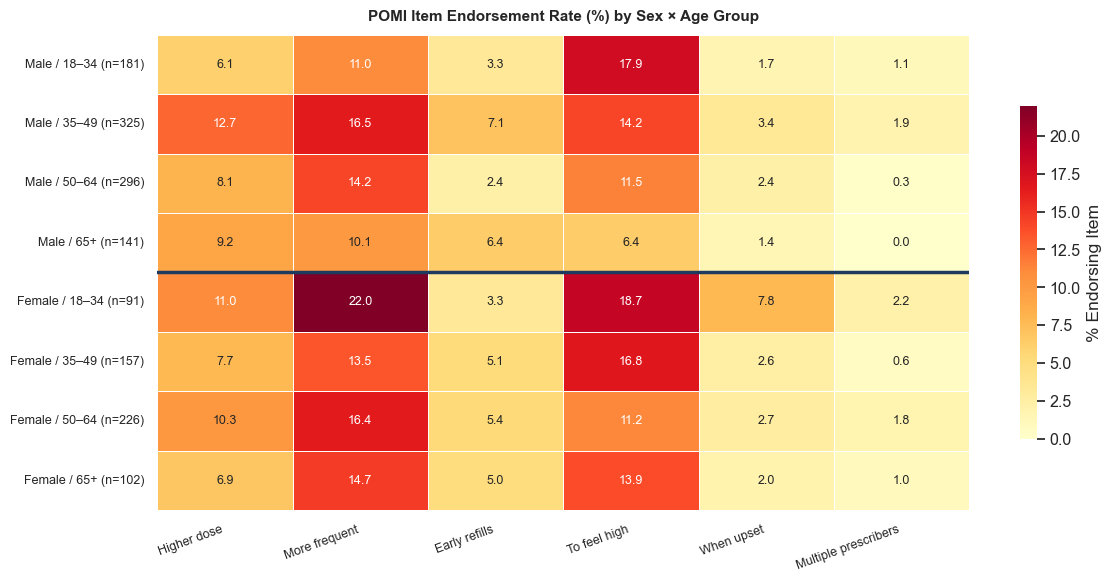

Bold line separates Male (above) from Female (below)


In [20]:
# ── 10b. POMI item endorsement heatmap by Sex ─────────────────────────────────
pomi_short = {
    'POMI_MORE_THAN_PRESCRIBED':  'Higher dose',
    'POMI_MORE_OFTEN_THAN_PRESCR':'More frequent',
    'POMI_EARLY_REFILLS':          'Early refills',
    'POMI_FEEL_HIGH':              'To feel high',
    'POMI_UPSET':                  'When upset',
    'POMI_MULTIPLE_PHYSICIANS':    'Multiple prescribers',
}

# Age groups
df['AGE_GROUP'] = pd.cut(df['AGEATCONSENT'],
                         bins=[17, 34, 49, 64, 100],
                         labels=['18–34', '35–49', '50–64', '65+'])

pomi_hm_rows = {}
for sex, sex_lbl in [(0,'Male'),(1,'Female')]:
    for age_grp in ['18–34','35–49','50–64','65+']:
        mask = (df['DEMOG_SEX']==sex) & (df['AGE_GROUP']==age_grp)
        sub = df[mask]
        n_sub = len(sub)
        if n_sub < 5:
            continue
        row_lbl = f'{sex_lbl} / {age_grp} (n={n_sub})'
        pomi_hm_rows[row_lbl] = {
            short_lbl: 100*(sub[col]==1).sum()/sub[col].notna().sum()
            for col, short_lbl in pomi_short.items()
        }

pomi_hm = pd.DataFrame(pomi_hm_rows).T

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    pomi_hm,
    ax=ax,
    cmap='YlOrRd',
    vmin=0,
    annot=True,
    fmt='.1f',
    annot_kws={'size': 9},
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': '% Endorsing Item', 'shrink': 0.7}
)
ax.set_title('POMI Item Endorsement Rate (%) by Sex × Age Group',
             fontsize=11, fontweight='bold', pad=10)

# Divider between male and female
n_male_rows = sum(1 for k in pomi_hm_rows if k.startswith('Male'))
ax.axhline(n_male_rows, color='#1E3A5F', linewidth=2.5)

ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('fig_heatmap_pomi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bold line separates Male (above) from Female (below)')

## 11. Summary Table & Export

In [21]:
summary_rows = []

def add_row(domain, metric, value, n):
    summary_rows.append({'Domain': domain, 'Metric': metric, 'Value': value, 'N': n})

# Demographics
add_row('Demographics', 'Age — mean (SD)', f"{df['AGEATCONSENT'].mean():.1f} ({df['AGEATCONSENT'].std():.1f})", N)
add_row('Demographics', '% Female', f"{100*(df['DEMOG_SEX']==1).sum()/N:.1f}%", N)
add_row('Demographics', '% White', f"{100*(df['DEMOG_RACE']==4).sum()/N:.1f}%", N)
add_row('Demographics', '% Hispanic', f"{100*(df['DEMOG_ETHNICITY']==1).sum()/N:.1f}%", N)
add_row('Demographics', '% Insured', f"{100*(df['DEMOG_ARE_YOU_INSURED']==1).sum()/N:.1f}%", N)

# Recruitment
add_row('Recruitment', '% In-person pharmacy initiation', f"{100*(df['INIT_AT_PHARMACY_YN']==1).sum()/N:.1f}%", N)
add_row('Recruitment', '% Preferred SMS/Text', f"{100*(df['INVITATION_PREFERENCE']==1).sum()/df['INVITATION_PREFERENCE'].notna().sum():.1f}%",
        int(df['INVITATION_PREFERENCE'].notna().sum()))

# BPI
n_bpi = df['BPI_PAINSCALE_WORST'].notna().sum()
add_row('Pain (BPI)', 'Worst pain — mean (SD)', f"{df['BPI_PAINSCALE_WORST'].mean():.2f} ({df['BPI_PAINSCALE_WORST'].std():.2f})", n_bpi)
add_row('Pain (BPI)', 'Average pain — mean (SD)', f"{df['BPI_PAINSCALE_AVERAGE'].mean():.2f} ({df['BPI_PAINSCALE_AVERAGE'].std():.2f})", n_bpi)
add_row('Pain (BPI)', 'Interference mean — mean (SD)', f"{df['BPI_INTERFERENCE_MEAN'].mean():.2f} ({df['BPI_INTERFERENCE_MEAN'].std():.2f})",
        int(df['BPI_INTERFERENCE_MEAN'].notna().sum()))

# ASSIST
add_row('Substance Use (ASSIST)', '% Ever Rx Opioid', f"{100*(df['ASSIST_EVER_RX_OPIOID']==3).sum()/df['ASSIST_EVER_RX_OPIOID'].notna().sum():.1f}%",
        int(df['ASSIST_EVER_RX_OPIOID'].notna().sum()))
add_row('Substance Use (ASSIST)', '% Ever Alcohol', f"{100*(df['ASSIST_EVER_ALCOHOL']==3).sum()/df['ASSIST_EVER_ALCOHOL'].notna().sum():.1f}%",
        int(df['ASSIST_EVER_ALCOHOL'].notna().sum()))
add_row('Substance Use (ASSIST)', '% Ever Tobacco', f"{100*(df['ASSIST_EVER_TOBACCO']==3).sum()/df['ASSIST_EVER_TOBACCO'].notna().sum():.1f}%",
        int(df['ASSIST_EVER_TOBACCO'].notna().sum()))
add_row('Substance Use (ASSIST)', '% Ever injected', f"{100*(df['ASSIST_INJECT'].isin([1,2])).sum()/N:.1f}%", N)

# POMI
n_pomi = df['POMI_TOTAL'].notna().sum()
add_row('Opioid Misuse (POMI)', '% Any misuse behavior', f"{100*df['POMI_ANY'].mean():.1f}%", n_pomi)
add_row('Opioid Misuse (POMI)', 'POMI total — mean (SD)', f"{df['POMI_TOTAL'].mean():.2f} ({df['POMI_TOTAL'].std():.2f})", n_pomi)

# PHQ-2
n_phq = df['PHQ2_TOTAL'].notna().sum()
add_row('Depression (PHQ-2)', 'PHQ-2 mean (SD)', f"{df['PHQ2_TOTAL'].mean():.2f} ({df['PHQ2_TOTAL'].std():.2f})", n_phq)
add_row('Depression (PHQ-2)', '% Positive screen (≥3)', f"{100*(df['PHQ2_TOTAL']>=3).sum()/n_phq:.1f}%", n_phq)

# Overdose
od_n = df['OESWD_PERSONAL_OVERDOSES'].notna().sum()
add_row('Overdose History', '% Any personal overdose', f"{100*(df['OESWD_PERSONAL_OVERDOSES']>0).sum()/od_n:.1f}%", od_n)

# NarxScore
add_row('NarxScore', 'Mean (SD)', f"{narx.mean():.1f} ({narx.std():.1f})", len(narx))
add_row('NarxScore', '% High risk (>400)', f"{100*(narx>400).sum()/len(narx):.1f}%", len(narx))

summary_df = pd.DataFrame(summary_rows)
print('CTN0093 — HDP01288 Secondary Analysis Summary')
display(summary_df.set_index(['Domain','Metric']))

summary_df.to_csv('HDP01288_summary.csv', index=False)
print('\nExported: HDP01288_summary.csv')
print('\nFigures saved:')
for f in ['fig_demographics','fig_recruitment','fig_bpi','fig_assist',
           'fig_pomi','fig_phq2','fig_health_overdose','fig_narxscore',
           'fig_heatmap_outcomes','fig_heatmap_pomi']:
    print(f'  {f}.png')

CTN0093 — HDP01288 Secondary Analysis Summary


Value     N
Domain                 Metric                                              
Demographics           Age — mean (SD)                    49.4 (14.9)  1523
                       % Female                                 37.8%  1523
                       % White                                  92.5%  1523
                       % Hispanic                                0.9%  1523
                       % Insured                                93.8%  1523
Recruitment            % In-person pharmacy initiation          26.7%  1523
                       % Preferred SMS/Text                     57.5%  1515
Pain (BPI)             Worst pain — mean (SD)             6.31 (2.55)  1519
                       Average pain — mean (SD)           4.73 (2.40)  1519
                       Interference mean — mean (SD)      4.81 (2.76)  1517
Substance Use (ASSIST) % Ever Rx Opioid                         66.4%  1514
                       % Ever Alcohol                           76.0%  1514
                       % Ever Tobacco                           59.4%  1514
                       % Ever injected                           3.8%  1523
Opioid Misuse (POMI)   % Any misuse behavior                    27.0%  1523
                       POMI total — mean (SD)             0.46 (0.92)  1523
Depression (PHQ-2)     PHQ-2 mean (SD)                    1.39 (1.79)  1493
                       % Positive screen (≥3)                   19.9%  1493
Overdose History       % Any personal overdose                   9.8%  1516
NarxScore              Mean (SD)                        275.1 (146.9)  1464
                       % High risk (>400)                       22.7%  1464


Exported: HDP01288_summary.csv

Figures saved:
  fig_demographics.png
  fig_recruitment.png
  fig_bpi.png
  fig_assist.png
  fig_pomi.png
  fig_phq2.png
  fig_health_overdose.png
  fig_narxscore.png
  fig_heatmap_outcomes.png
  fig_heatmap_pomi.png
